<a href="https://colab.research.google.com/github/divyasri-jonnadula-16/spoken-language-identification/blob/main/MLPClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import librosa
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report


In [ ]:
!pip install librosa soundfile numpy pandas scikit-learn matplotlib tqdm


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

TRAIN_PATH = "/content/drive/MyDrive/spokenvoice/train"
TEST_PATH  = "/content/drive/MyDrive/spokenvoice/test"


In [ ]:
def trim_audio(y, sr, duration):
    max_len = int(sr * duration)
    return y[:max_len] if len(y) > max_len else y

def add_noise(y, noise_factor=0.005):
    noise = np.random.randn(len(y))
    return y + noise_factor * noise


In [ ]:
def extract_mfcc(y, sr, n_mfcc=40):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return np.mean(mfcc.T, axis=0)


In [ ]:
def load_dataset(path,
                 duration=3,
                 use_noise=False,
                 max_files_per_language=None):
    X, y = [], []
    sr = 22050  # dataset sample rate

    for language in sorted(os.listdir(path)):
        lang_path = os.path.join(path, language)
        if not os.path.isdir(lang_path):
            continue

        files = [
            f for f in os.listdir(lang_path)
            if f.lower().endswith(".flac")
        ]

        if max_files_per_language:
            random.shuffle(files)
            files = files[:max_files_per_language]

        for file in tqdm(files, desc=f"Loading {language}"):
            file_path = os.path.join(lang_path, file)

            audio, _ = librosa.load(file_path, sr=sr)
            audio = trim_audio(audio, sr, duration)

            if use_noise:
                audio = add_noise(audio)

            features = extract_mfcc(audio, sr)

            X.append(features)
            y.append(language)

    return np.array(X), np.array(y)


In [ ]:
X_train, y_train = load_dataset(
    TRAIN_PATH,
    duration=3,
    use_noise=False,
    max_files_per_language=300   # optional but recommended
)

X_test, y_test = load_dataset(
    TEST_PATH,
    duration=3,
    use_noise=False
)


Loading spanish: 100%|██████████| 180/180 [00:06<00:00, 27.29it/s]


In [ ]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)


In [ ]:
model = MLPClassifier(
    hidden_layer_sizes=(256,),
    max_iter=300,
    random_state=42
)

model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(256,), max_iter=300, random_state=42)

In [ ]:
preds = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds, target_names=le.classes_))


Accuracy: 0.4777777777777778
              precision    recall  f1-score   support

     english       0.43      0.65      0.52       180
      german       0.45      0.23      0.31       180
     spanish       0.56      0.55      0.56       180

    accuracy                           0.48       540
   macro avg       0.48      0.48      0.46       540
weighted avg       0.48      0.48      0.46       540



In [ ]:
print("Train samples:", X_train.shape)
print("Test samples:", X_test.shape)
print("Languages:", le.classes_)


Train samples: (900, 40)
Test samples: (540, 40)
Languages: ['english' 'german' 'spanish']


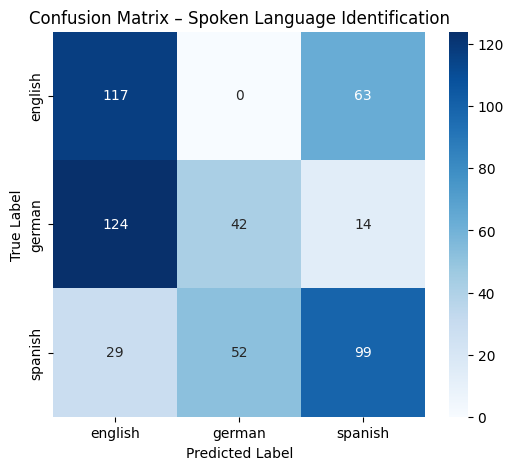

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix – Spoken Language Identification")
plt.show()


Loading spanish: 100%|██████████| 180/180 [00:05<00:00, 33.48it/s]


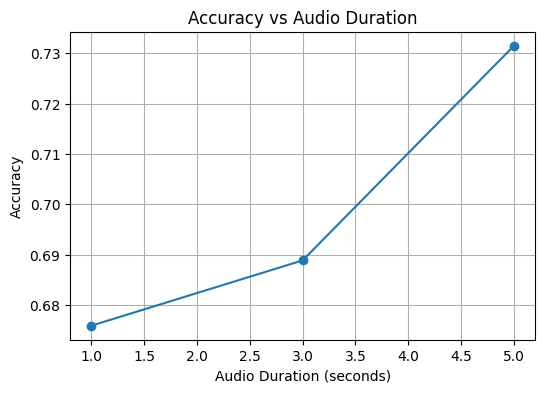

In [ ]:
durations = [1, 3, 5]
accuracies = []

for d in durations:
    X_tr, y_tr = load_dataset(TRAIN_PATH, duration=d, max_files_per_language=300)
    X_te, y_te = load_dataset(TEST_PATH, duration=d)

    y_tr = le.fit_transform(y_tr)
    y_te = le.transform(y_te)

    model = MLPClassifier(hidden_layer_sizes=(256,), max_iter=300)
    model.fit(X_tr, y_tr)

    preds_d = model.predict(X_te)
    acc = accuracy_score(y_te, preds_d)
    accuracies.append(acc)

plt.figure(figsize=(6,4))
plt.plot(durations, accuracies, marker="o")
plt.xlabel("Audio Duration (seconds)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Audio Duration")
plt.grid(True)
plt.show()


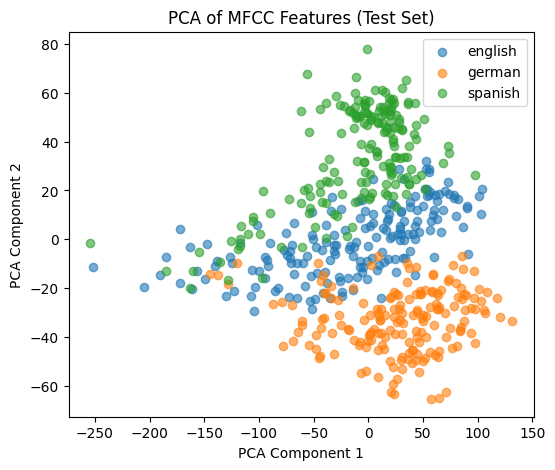

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_test)

plt.figure(figsize=(6,5))
for idx, lang in enumerate(le.classes_):
    plt.scatter(
        X_pca[y_test == idx, 0],
        X_pca[y_test == idx, 1],
        label=lang,
        alpha=0.6
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA of MFCC Features (Test Set)")
plt.legend()
plt.show()
